# Draft

In [ ]:
import glob
from pathlib import Path

import ot
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram

from src.repartition.data_loading import get_annotation, tif_to_real_mask
from src.repartition.data_analysis import *
from src.repartition.visualization import plot_distribution, plot_tumor_slide_grid, \
                                            export_furthest_tissue_pdf, export_mask_pdf, \
                                            export_tissues_proportion
from src.repartition.constants import PROJECT_ROOT, PATH_PATIENT_DATA
from src.repartition.TissueCollection import * 

In [2]:
%load_ext autoreload
%autoreload 1
%aimport src.repartition.data_loading, src.repartition.data_analysis, src.repartition.visualization, src.repartition.constants, src.repartition.TissueCollection

## Load paths

In [3]:
project_root = PROJECT_ROOT
annot_dir = project_root / 'data/repartition/annotation/'
annotations_paths = glob.glob(str(annot_dir) + "/" +'*.tif')
annotations_paths = np.array(annotations_paths)
slides_annot = get_annotation(annotations_paths, tif_to_real_mask)

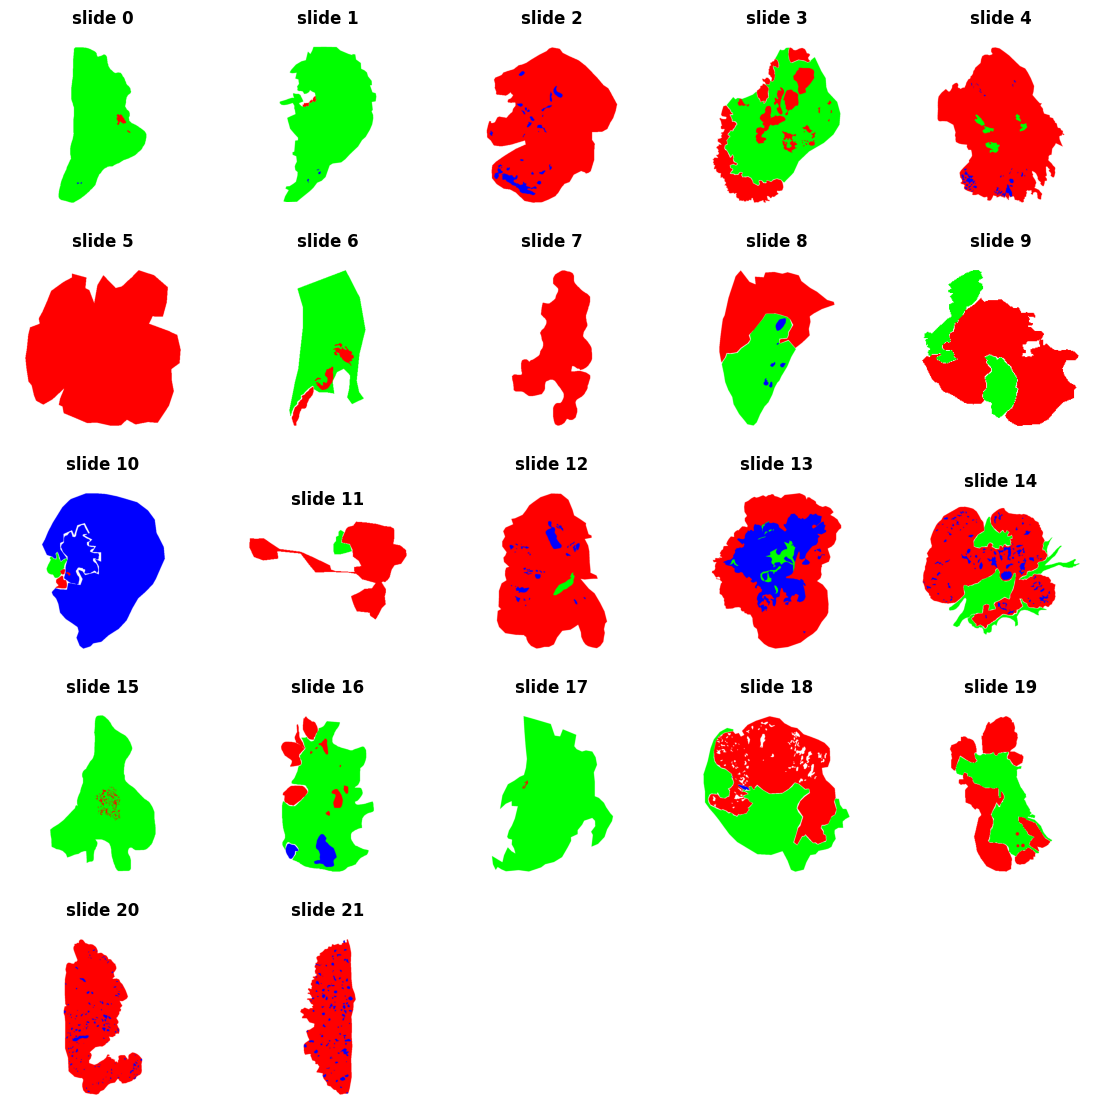

In [4]:
plot_tumor_slide_grid(slides_annot) 

In [4]:
distance_data, distribution_data_local = get_tissues_data(slides_annot, return_kde=True, local_ratio=True)
#_, distribution_data_global = get_tissues_data(slides_annot, return_kde=True, local_ratio=False)
#distance_data.to_csv('tissues_info.csv')

Corrigés   : 2 '/' 2
Encore > 1 : 0
Corrigés   : 31677 '/' 31677
Encore > 1 : 2
Corrigés   : 441 '/' 441
Encore > 1 : 1
Corrigés   : 441 '/' 441
Encore > 1 : 1
Corrigés   : 268 '/' 268
Encore > 1 : 0
Corrigés   : 268 '/' 268
Encore > 1 : 0
Corrigés   : 10 '/' 10
Encore > 1 : 0
Corrigés   : 5136 '/' 5136
Encore > 1 : 2
Corrigés   : 5136 '/' 5136
Encore > 1 : 2
Corrigés   : 353 '/' 353
Encore > 1 : 1
Corrigés   : 353 '/' 353
Encore > 1 : 1
Corrigés   : 41 '/' 41
Encore > 1 : 0
Corrigés   : 41 '/' 41
Encore > 1 : 0
Corrigés   : 911 '/' 911
Encore > 1 : 1
Corrigés   : 13311 '/' 13311
Encore > 1 : 0
Corrigés   : 13311 '/' 13311
Encore > 1 : 0
Corrigés   : 151 '/' 151
Encore > 1 : 1
Corrigés   : 151 '/' 151
Encore > 1 : 1
Corrigés   : 1 '/' 1
Encore > 1 : 0
Corrigés   : 2 '/' 2
Encore > 1 : 0
Corrigés   : 2 '/' 2
Encore > 1 : 0
Corrigés   : 56 '/' 56
Encore > 1 : 0
Corrigés   : 2 '/' 2
Encore > 1 : 0
Corrigés   : 4162 '/' 4162
Encore > 1 : 1
Corrigés   : 4162 '/' 4162
Encore > 1 : 1
Corrigés

In [47]:
export_mask_pdf(
    slides_annot,
    output="masks.pdf"
)

In [173]:
export_furthest_tissue_pdf(
    slides_annot, 
    distance_data, 
    tissue_type='tumor',
    output="furthest_tumors.pdf",
    saveimg=True
)

In [174]:
all_tissue_areas = get_areas(distance_data)
export_tissues_proportion(
    all_tissue_areas, 
    draw_type='bar',
    saveimg=True
)

In [ ]:
furthest_tum = get_furthest_tumors(distance_data, by='id-slide')
furthest_tum.to_csv('furthest_tumors.csv')

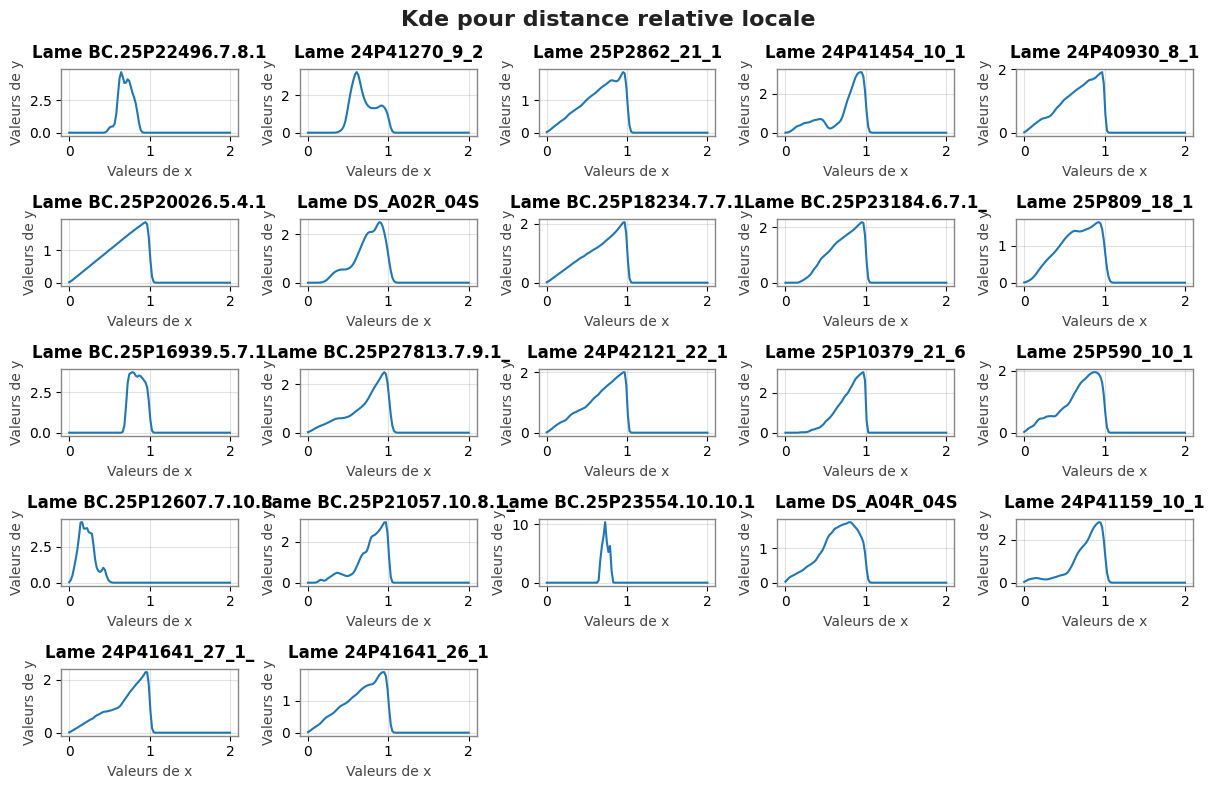

In [5]:
plot_distribution(distribution_data_local, show='kde', ref='center', suptitle="Kde pour distance relative locale")

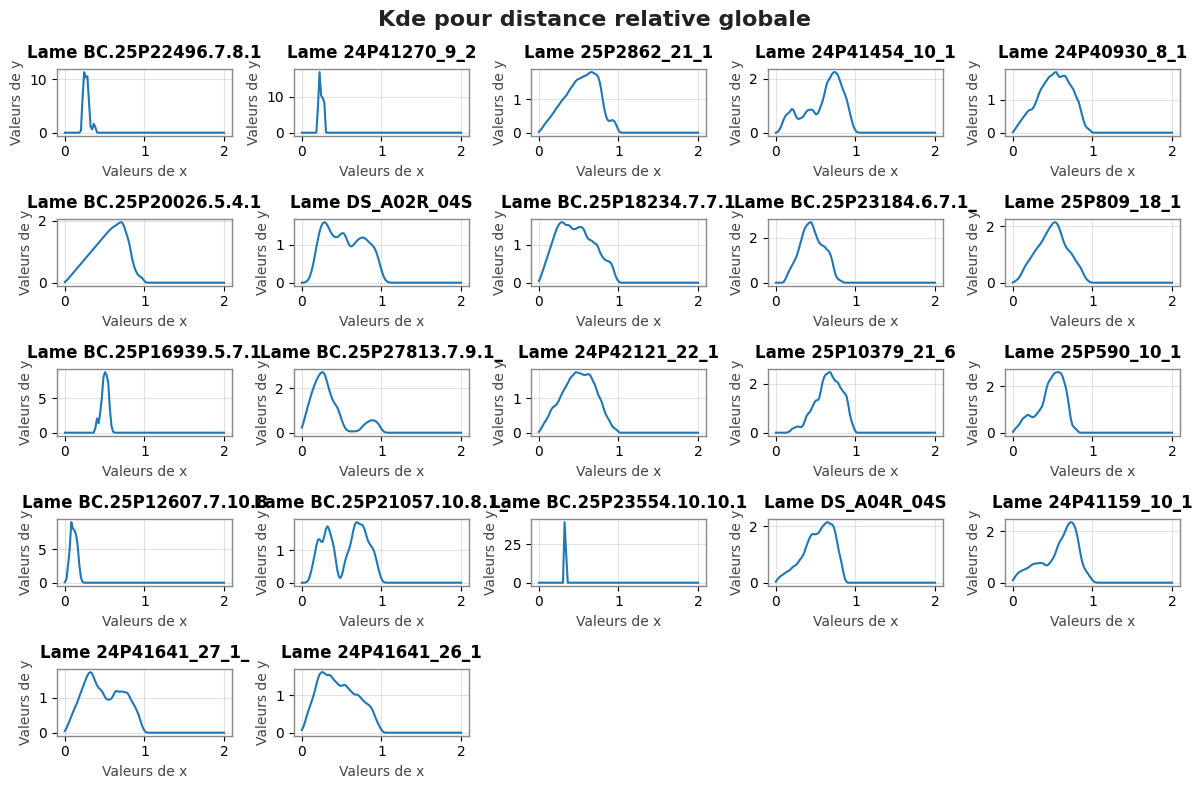

In [105]:
plot_distribution(distribution_data_global, show='kde', ref='center', suptitle="Kde pour distance relative globale")

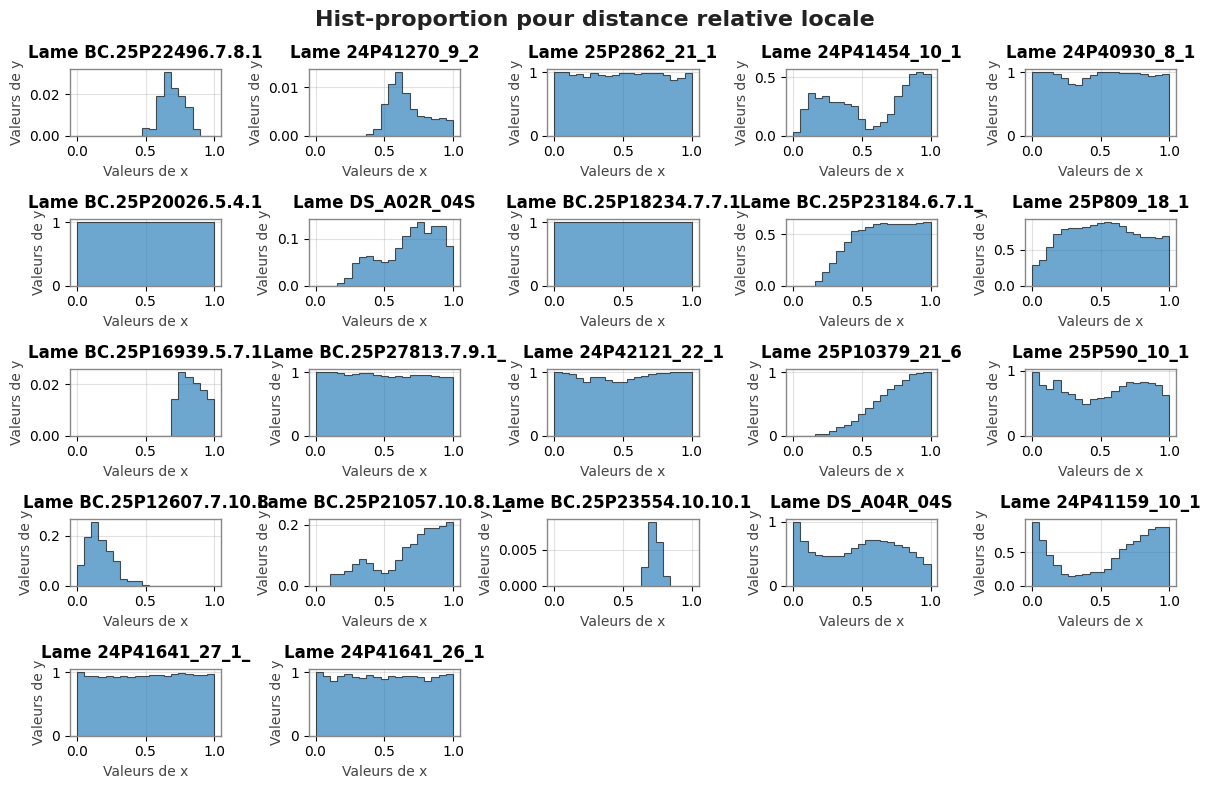

In [104]:
plot_distribution(distribution_data_local, show='hist-proportion', suptitle="Hist-proportion pour distance relative locale")

In [100]:
eval_points = np.linspace(0, 1, 50)
bins = np.linspace(0, 1, 20)
# [0.6, 0, 0.4] ou [0.5, 0, 0.5]
other_w = 0.5
weights = [1-other_w, 0.0, other_w]
kde_vec_local, hist_vec, other_feats = extract_features(distribution_data_local, eval_points, bins,
                                                distance_data=distance_data, slides_annot=slides_annot,
                                                only_distrib=False)

""" kde_vec_global, hist_vec, other_feats = extract_features(distribution_data_global, eval_points, bins,
                                                distance_data=distance_data, slides_annot=slides_annot,
                                                only_distrib=False) """

feat2 = extract_features2(slides_annot, [0.1], distance_data)

dist_matrix = compute_distance_matrix(
    kde_vec_local, hist_vec, 
    weights, eval_points, bins, 
    additional_feats=feat2
)

dist_matrix2 = compute_distance_matrix2(
    kde_vec_local, eval_points, 
    other_feats[:, 0],
)

In [101]:
clustering = AgglomerativeClustering(
    n_clusters=6,
    metric='precomputed',
    linkage='average'           # 'ward' incompatible avec precomputed
)
labels_agglo = clustering.fit_predict(dist_matrix)

clustering = DBSCAN(eps=0.1, min_samples=1, metric='precomputed')
labels_dbscan = clustering.fit_predict(dist_matrix)


mds = MDS(n_components=2, metric='precomputed', random_state=42, n_init=1, init='classical_mds')
X_mds = mds.fit_transform(dist_matrix)

tsne = TSNE(n_components=2, metric='precomputed', random_state=42, perplexity=5, init=X_mds)
X_tsne = tsne.fit_transform(dist_matrix)


In [109]:
clustering = AgglomerativeClustering(
    n_clusters=6,
    metric='euclidean',
    linkage='average'
)
labels_agglo2 = clustering.fit_predict(feat2)

clustering = DBSCAN(eps=0.1, min_samples=1)
labels_dbscan = clustering.fit_predict(feat2)


mds = MDS(n_components=2, metric='euclidean', random_state=42, n_init=1, init='classical_mds')
X_mds2 = mds.fit_transform(feat2)

tsne = TSNE(n_components=2, metric='euclidean', random_state=42, perplexity=5, init='pca')
X_tsne2 = tsne.fit_transform(feat2)

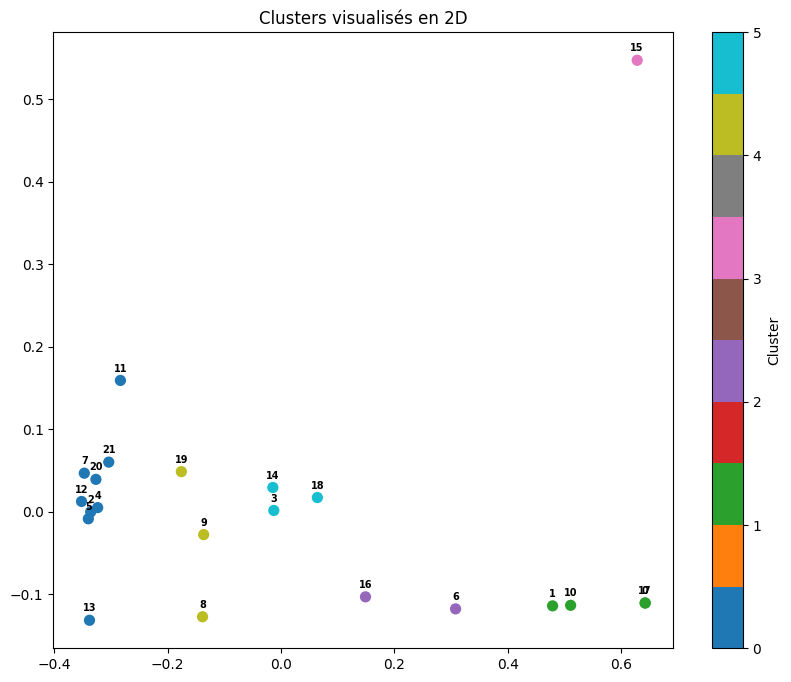

In [110]:
X = X_mds2
labels = labels_agglo2

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=50)
plt.colorbar(scatter, label='Cluster')

for i, (x, y) in enumerate(X):
    ax.annotate(str(i), (x, y), fontsize=7, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

plt.title('Clusters visualisés en 2D')
plt.show()

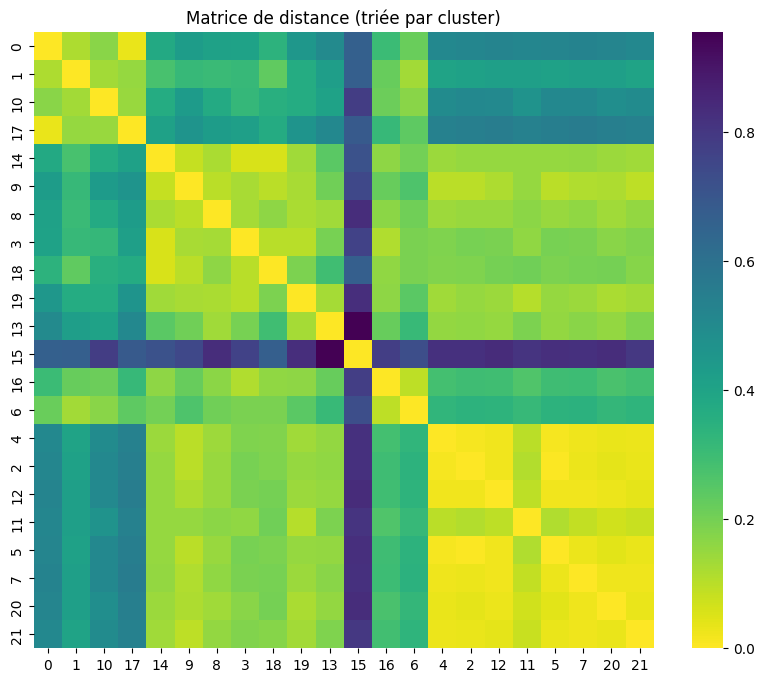

In [108]:
order = np.argsort(labels_agglo)
plt.figure(figsize=(10, 8))
sns.heatmap(
    dist_matrix[order][:, order],
    cmap='viridis_r',
    xticklabels=order,
    yticklabels=order
)
plt.title('Matrice de distance (triée par cluster)')

plt.show()

In [ ]:
mds.stress_

In [ ]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [ ]:
plot_dendrogram(clustering, truncate_mode="level", p=6)

In [ ]:
dist_2d = pairwise_distances(X)

orig = dist_matrix
proj = mds.dissimilarity_matrix_

plt.scatter(orig, proj, alpha=0.5)
plt.plot([orig.min(), orig.max()], [orig.min(), orig.max()], 'r--')
plt.xlabel("Distances originales")
plt.ylabel("Distances projetées")
plt.title("Shepard plot — idéalement tous les points sur la diagonale")

In [136]:
score = silhouette_score(dist_matrix, labels_agglo, metric='precomputed')
print(f"Silhouette : {score:.3f}")  # Entre -1 et 1, > 0.5 = bons clusters

Silhouette : 0.447


# Processing patient data

In [111]:
data = pd.read_excel(PATH_PATIENT_DATA)

In [112]:
cols_to_drop = ['En attente', 'Anonymisation', 'Sexe', 'Annee de naissance',
                'Annee du sevrage', 'Année de diagnostic',
                'PA', 'Année de diagnostic', 'Age au diagnostic', 'Methode diagnostic',
                'Taille tumorale après TTT (en mm)', 'Taille du lit tumoral (en mm)']

data.drop(columns=cols_to_drop, inplace=True)

In [113]:
cols_to_select = [
    'Patient',
    'Type histologique', 'Stade clinique',
    'Type de chirurgie', 'Regression pathologique'
]

data_light = data[cols_to_select]
data_light.dropna(inplace=True)
data_light['Patient'] = data_light['Patient'].str.strip()

In [114]:
tumors = get_furthest_tumors(distance_data, by='id-slide')

In [115]:
tumors = tumors.merge(data_light, how='inner', left_on='id-patient', right_on='Patient')

In [139]:
tumors.index

RangeIndex(start=0, stop=20, step=1)

/tmp/ipykernel_186304/2962698854.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right');


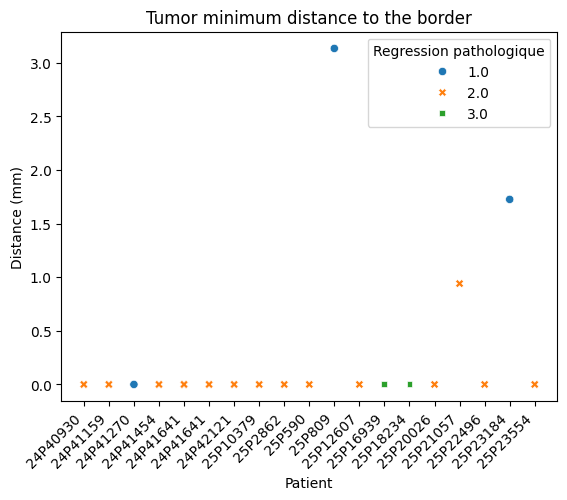

In [152]:
labels = tumors['Patient']
x = np.arange(len(labels))
ax = sns.scatterplot(
    tumors, x='Patient', y='distance-border', 
    hue='Regression pathologique', style='Regression pathologique',
    palette=sns.color_palette(n_colors=3),
)
ax.set_title('Tumor minimum distance to the border')
ax.set_ylabel('Distance (mm)')
ax.set_xticklabels(labels, rotation=45, ha='right');

In [8]:
def get_label_patient(label, distribution_data, data_light):
    df_light = {row['Patient'].strip(): row.drop('Patient').to_dict() for i, row in data_light.iterrows()}
    labels = [df_light[id_patient(sld_name)][label] for sld_name in distribution_data 
              if id_patient(sld_name) in df_light]
    return labels

In [49]:
distribution_data_filtered = {k: v for k, v in distribution_data.items() if id_patient(k) in data_light['Patient'].values}

## Clustering - Optimal Transport

In [156]:
grid = np.linspace(0, 2, 100)
X = np.array([
    dist['kde']['center'](grid) 
    for _, dist in distribution_data_local.items()
])

for row in X:
    row /= row.sum()

X = X.T

Début du clustering...
Convergence atteinte à l'itération 3.


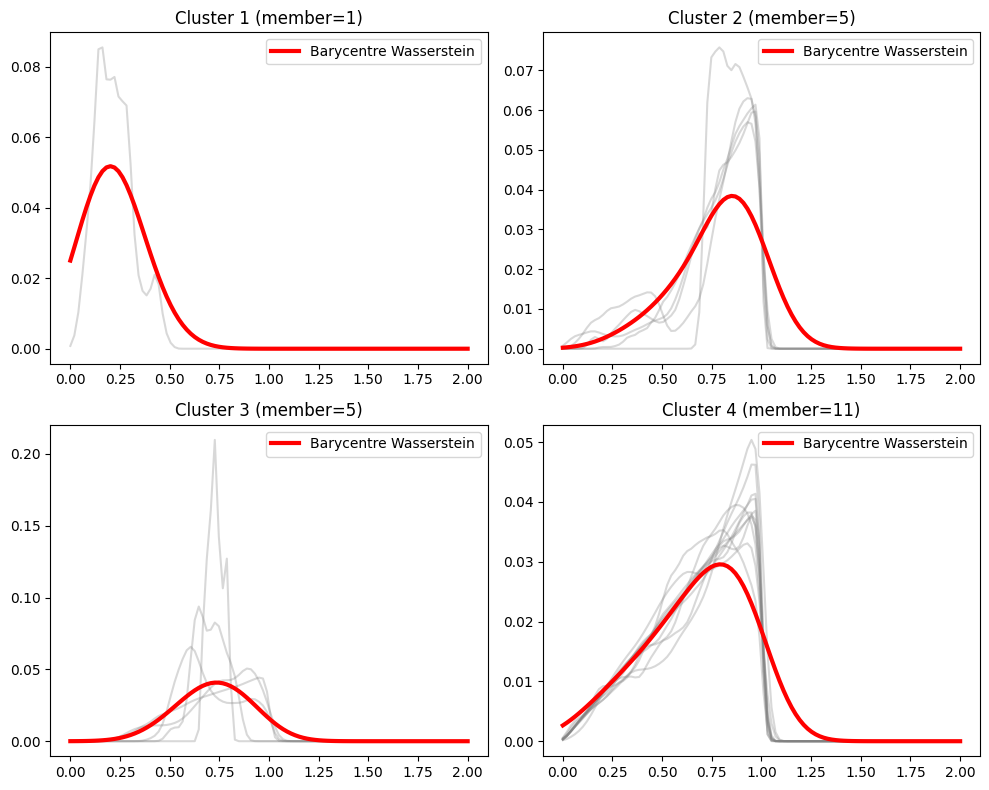

In [178]:
d, N = X.shape
K = 4                  # Nombre de clusters
max_iter = 50          # Nombre maximum d'itérations
reg = 1e-2             # Paramètre de régularisation entropique (Sinkhorn)
M = ot.dist(grid.reshape((d, 1)), grid.reshape((d, 1)))
M /= np.max(M)
method = 'sinkhorn_log'
# ==========================================
# Algorithme K-Means avec Transport Optimal
# ==========================================
print("Début du clustering...")

init_indices = np.random.choice(N, K, replace=False)
centers = X[:, init_indices].copy()
labels = np.zeros(N)

for iteration in range(max_iter):
    
    # --- ÉTAPE 1 : Assignation ---
    distances = np.zeros((N, K))
    for i in range(N):
        for k in range(K):
            distances[i, k] = ot.sinkhorn2(
                X[:, i], centers[:, k], M, reg, 
                method=method,
            )
            
    new_labels = np.argmin(distances, axis=1)
    
    if np.array_equal(labels, new_labels):
        print(f"Convergence atteinte à l'itération {iteration}.")
        break
    labels = new_labels
    
    # --- ÉTAPE 2 : Mise à jour (Barycentres de Wasserstein) ---
    for k in range(K):
        cluster_data = X[:, labels == k]
        if cluster_data.shape[1] > 0:
            centers[:, k] = ot.bregman.barycenter(
                cluster_data, M, reg,
                method=method
            )

labels_ot_kmeans = labels

# Visualisation
plt.figure(figsize=(10, 8))
cols = math.ceil(math.sqrt(K))
rows = math.ceil(K / cols)
for k in range(K):
    plt.subplot(rows, cols, k+1)
    cluster_data = X[:, labels == k]
    
    # Afficher les distributions du cluster
    for i in range(cluster_data.shape[1]):
        plt.plot(grid, cluster_data[:, i], color='gray', alpha=0.3)
        
    # Afficher le barycentre
    plt.plot(grid, centers[:, k], color='red', linewidth=3, label='Barycentre Wasserstein')
    
    plt.title(f'Cluster {k+1} (member={cluster_data.shape[1]})')
    plt.legend()

plt.tight_layout()
plt.show()

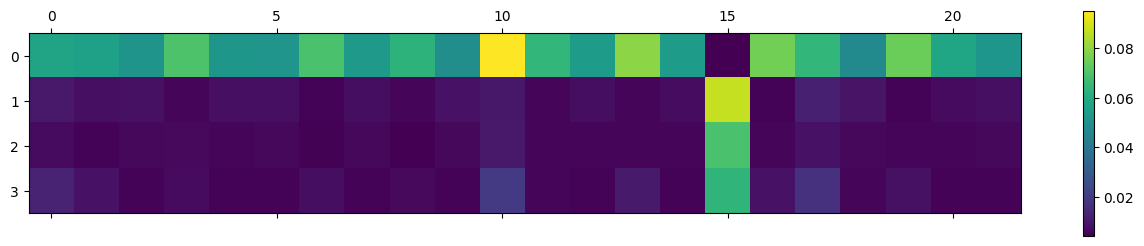

In [179]:
plt.matshow(distances.T)
plt.colorbar()